In [1]:
# forçando o repositorio a encontrar src
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#from utils.analytics.Plot3d import Plot3d

In [3]:
data_path = os.path.join('data', 'raw', 'dados_completos.csv')
df = pd.read_csv("C:\\Users\\souza\\OneDrive\\Área de Trabalho\\modelagem inadimplencia\\data\\raw\\dados_completos.csv")
df = df.rename(columns={'4393': 'Confiança_consumidor', 
                        '21084':'Inadimplencia_PF', 
                        '24369':'Desemprego',
                        '27640':'Juros_nao_rotativos_PF',
                        '4390':'SELIC', 
                        '24364':'IBC-Br'})
df = df.set_index('data')
df = df.dropna()
X = df.drop(['Inadimplencia_PF', 'Juros_nao_rotativos_PF'], axis=1)
# X.insert(0, 'intercepto', 1)
X_train = X.loc['2012-03-01':'2026-01-01']
X_test = X.loc['2026-02-01':]
y = df['Inadimplencia_PF']
y_train = y.loc['2012-03-01':'2026-01-01']
y_test = y.loc['2026-02-01':]


In [5]:
X_train['PANDEMIA'] = np.where((X_train.index >= '2020-03-01')&(X_train.index <='2023-04-01'), 1,0)
X_test.insert(4, 'PANDEMIA', 0)

In [9]:
# criando funçao para previsao direta do modelo
def model_MQO(X:pd.DataFrame):
    return 11.385093  + 0.020376  * X['Confiança_consumidor'] + (-0.124835 * X['Desemprego']) + 0.678294 * X['SELIC'] + (-0.091761 * X['IBC-Br']) + X['PANDEMIA']*-0.185828

<Axes: xlabel='data'>

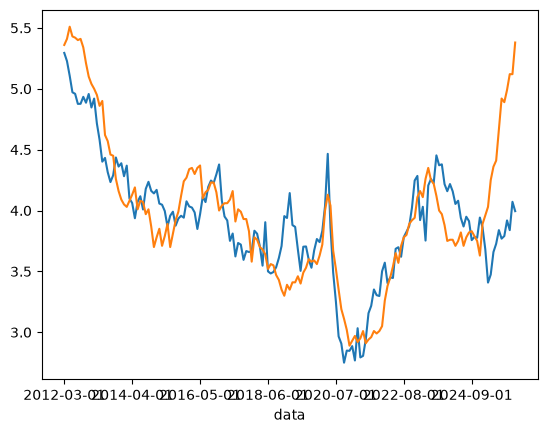

In [10]:
y_pred_train = model_MQO(X_train)
y_pred_train.plot()
y_train.plot()



<Axes: xlabel='data'>

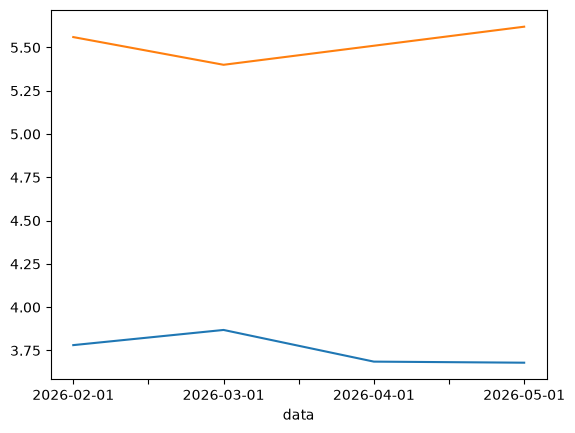

In [11]:
y_pred_test = model_MQO(X_test)
y_pred_test.plot()
y_test.plot()

In [ ]:
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Confiança_consumidor,4.0,123.717500,3.426168,120.55000,120.932500,123.46500,126.250000,127.39000
Desemprego,4.0,5.825000,0.206155,5.60000,5.750000,5.80000,5.875000,6.10000
Juros_nao_rotativos_PF,4.0,2.335000,0.028868,2.30000,2.322500,2.33500,2.347500,2.37000
SELIC,4.0,1.092500,0.087321,1.00000,1.052500,1.08000,1.120000,1.21000
IBC-Br,4.0,110.790722,0.247381,110.51078,110.621885,110.80812,110.976957,111.03587
PANDEMIA,4.0,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000


In [ ]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Confiança_consumidor,167.0,117.883533,18.272289,84.55000,106.77500,113.50000,127.16000,165.85000
Desemprego,167.0,9.710778,2.795759,5.10000,7.20000,8.90000,12.15000,14.90000
Juros_nao_rotativos_PF,167.0,1.855329,0.195617,1.43000,1.71500,1.83000,2.00500,2.33000
SELIC,167.0,0.768084,0.297558,0.13000,0.54000,0.81000,1.02500,1.28000
IBC-Br,167.0,99.540032,4.938874,83.03874,96.18714,99.08075,102.64316,110.09056
PANDEMIA,167.0,0.227545,0.420508,0.00000,0.00000,0.00000,0.00000,1.00000


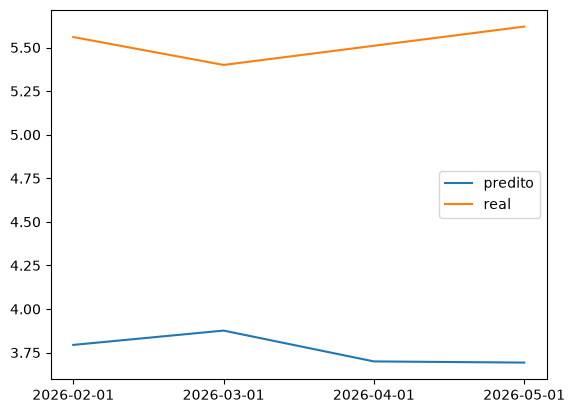

In [ ]:
plt.plot(y_pred_test, label='predito')
plt.plot(y_test, label='real')
plt.legend()